# Import Libraries & Load Data

In [1]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


# Load & Inspect the Raw Data

In [3]:
# Load the dataset
df_raw = pd.read_csv('student perf.csv', sep=';', quoting=3, encoding='utf-8')

# Clean up column names (strip quotes, whitespace, fix tab character)
df_raw.columns = [col.strip().strip('"').replace('\t', '').strip() for col in df_raw.columns]

print("Shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())

Shape: (4424, 37)

Columns:
 ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', '

In [4]:
# Check
df_raw.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# Data types and missing values
print("=== Data Types ===")
print(df_raw.dtypes)

print("\n=== Missing Values ===")
print(df_raw.isnull().sum())

print("\n=== Basic Stats ===")
df_raw.describe()

=== Data Types ===
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             i

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


# Data Cleaning

In [7]:
# Rename long and misspelled column names

df = df_raw.copy()

df.rename(columns={
    # Fix typo
    'Nacionality'                                    : 'Nationality',

    # Shorten attendance
    'Daytime/evening attendance'                     : 'Attendance type',

    # Shorten previous qualification
    'Previous qualification'                         : 'Prev qualification',
    'Previous qualification (grade)'                 : 'Prev qual grade',

    # Shorten parent columns
    "Mother's qualification"                         : 'Mother qualification',
    "Father's qualification"                         : 'Father qualification',
    "Mother's occupation"                            : 'Mother occupation',
    "Father's occupation"                            : 'Father occupation',

    # Shorten financial columns
    'Educational special needs'                      : 'Special needs',
    'Tuition fees up to date'                        : 'Tuition up to date',

    # Shorten all 1st semester curricular columns
    'Curricular units 1st sem (credited)'            : 'Sem1 credited',
    'Curricular units 1st sem (enrolled)'            : 'Sem1 enrolled',
    'Curricular units 1st sem (evaluations)'         : 'Sem1 evaluations',
    'Curricular units 1st sem (approved)'            : 'Sem1 approved',
    'Curricular units 1st sem (grade)'               : 'Sem1 grade',
    'Curricular units 1st sem (without evaluations)' : 'Sem1 no evaluations',

    # Shorten all 2nd semester curricular columns
    'Curricular units 2nd sem (credited)'            : 'Sem2 credited',
    'Curricular units 2nd sem (enrolled)'            : 'Sem2 enrolled',
    'Curricular units 2nd sem (evaluations)'         : 'Sem2 evaluations',
    'Curricular units 2nd sem (approved)'            : 'Sem2 approved',
    'Curricular units 2nd sem (grade)'               : 'Sem2 grade',
    'Curricular units 2nd sem (without evaluations)' : 'Sem2 no evaluations',
}, inplace=True)

print("✅ Columns renamed. Final column list:")
for col in df.columns:
    print(f"   → {col}")

✅ Columns renamed. Final column list:
   → Marital status
   → Application mode
   → Application order
   → Course
   → Attendance type
   → Prev qualification
   → Prev qual grade
   → Nationality
   → Mother qualification
   → Father qualification
   → Mother occupation
   → Father occupation
   → Admission grade
   → Displaced
   → Special needs
   → Debtor
   → Tuition up to date
   → Gender
   → Scholarship holder
   → Age at enrollment
   → International
   → Sem1 credited
   → Sem1 enrolled
   → Sem1 evaluations
   → Sem1 approved
   → Sem1 grade
   → Sem1 no evaluations
   → Sem2 credited
   → Sem2 enrolled
   → Sem2 evaluations
   → Sem2 approved
   → Sem2 grade
   → Sem2 no evaluations
   → Unemployment rate
   → Inflation rate
   → GDP
   → Target


In [8]:
# Check and fix duplicates
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (4424, 37)


In [10]:
# Decode binary columns to readable labels
# These columns use 1/0 encoding — let's make them human readable
binary_cols = {
    'Attendance type': {1: 'Daytime', 0: 'Evening'},
    'Displaced':                  {1: 'Yes', 0: 'No'},
    'Special needs':  {1: 'Yes', 0: 'No'},
    'Debtor':                     {1: 'Yes', 0: 'No'},
    'Tuition up to date':    {1: 'Yes', 0: 'No'},
    'Gender':                     {1: 'Male', 0: 'Female'},
    'Scholarship holder':         {1: 'Yes', 0: 'No'},
    'International':              {1: 'Yes', 0: 'No'},
}

for col, mapping in binary_cols.items():
    df[col] = df[col].map(mapping)

print("✅ Binary columns decoded")
df[list(binary_cols.keys())].head()

✅ Binary columns decoded


,Attendance type,Displaced,Special needs,Debtor,Tuition up to date,Gender,Scholarship holder,International
0,Daytime,Yes,No,No,Yes,Male,No,No
1,Daytime,Yes,No,No,No,Male,No,No
2,Daytime,Yes,No,No,No,Male,No,No
3,Daytime,Yes,No,No,Yes,Female,No,No
4,Evening,No,No,No,Yes,Female,No,No


✅ Binary columns decoded


,Attendance type,Displaced,Special needs,Debtor,Tuition up to date,Gender,Scholarship holder,International
0,Daytime,Yes,No,No,Yes,Male,No,No
1,Daytime,Yes,No,No,No,Male,No,No
2,Daytime,Yes,No,No,No,Male,No,No
3,Daytime,Yes,No,No,Yes,Female,No,No
4,Evening,No,No,No,Yes,Female,No,No


In [15]:
# Cell 8: Check Target column
print("Target value counts:")
print(df['Target'].value_counts())

print("\nTarget proportions:")
print(df['Target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Target value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target proportions:
Target
Graduate    49.9%
Dropout     32.1%
Enrolled    17.9%
Name: proportion, dtype: object


In [16]:
# Check for outliers in key numeric columns
numeric_cols = ['Age at enrollment', 'Admission grade',
                'Prev qual grade',
                'Sem1 grade',
                'Sem2 grade',
                'Unemployment rate', 'Inflation rate', 'GDP']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers detected")

Age at enrollment: 441 outliers detected
Admission grade: 86 outliers detected
Prev qual grade: 179 outliers detected
Sem1 grade: 726 outliers detected
Sem2 grade: 877 outliers detected
Unemployment rate: 0 outliers detected
Inflation rate: 0 outliers detected
GDP: 0 outliers detected


In [17]:
# Save clean dataset
df.to_csv('student perf_clean.csv', index=False)
print("✅ Clean dataset saved as 'student_perf_clean.csv'")
print("Final shape:", df.shape)

✅ Clean dataset saved as 'student_perf_clean.csv'
Final shape: (4424, 37)


# Exploratory Data Analysis (EDA)

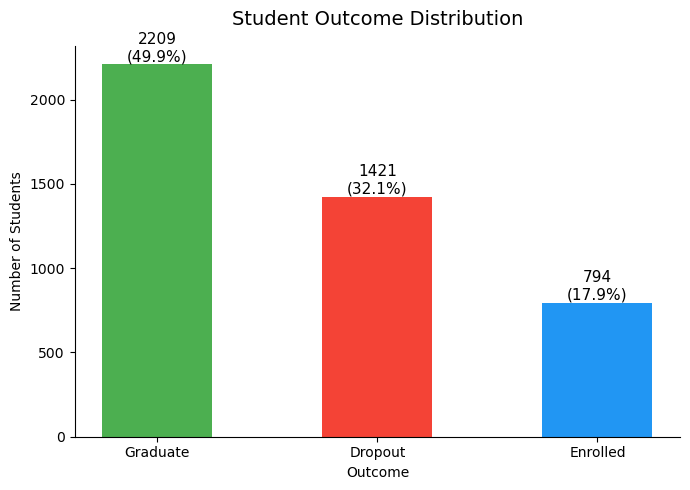

In [18]:
# Target distribution plot 
target_counts = df['Target'].value_counts()

colors = ['#4CAF50', '#F44336', '#2196F3']
plt.figure(figsize=(7, 5))
bars = plt.bar(target_counts.index, target_counts.values, color=colors, width=0.5)

for bar, val in zip(bars, target_counts.values):
    pct = f"{val/len(df)*100:.1f}%"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val}\n({pct})", ha='center', fontsize=11)

plt.title("Student Outcome Distribution", fontsize=14, pad=15)
plt.ylabel("Number of Students")
plt.xlabel("Outcome")
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150)
plt.show()

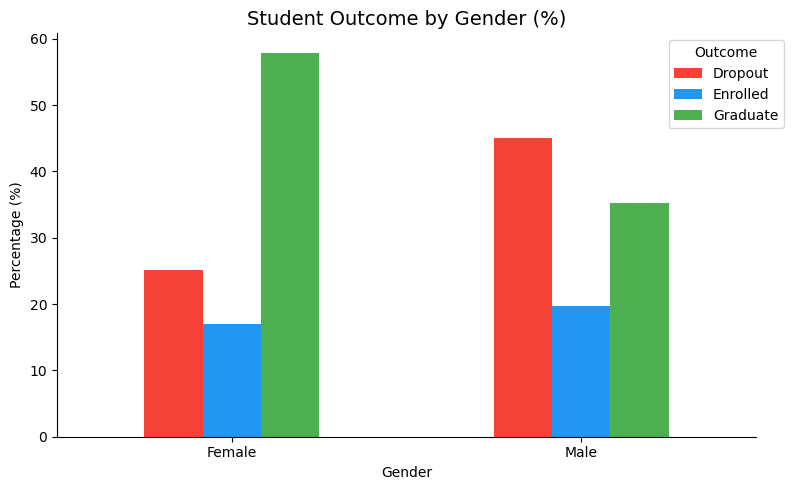

In [19]:
# Dropout rate by gender
gender_target = df.groupby(['Gender', 'Target']).size().unstack(fill_value=0)
gender_pct = gender_target.div(gender_target.sum(axis=1), axis=0) * 100

gender_pct.plot(kind='bar', figsize=(8, 5), color=['#F44336','#2196F3','#4CAF50'])
plt.title("Student Outcome by Gender (%)", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("02_outcome_by_gender.png", dpi=150)
plt.show()

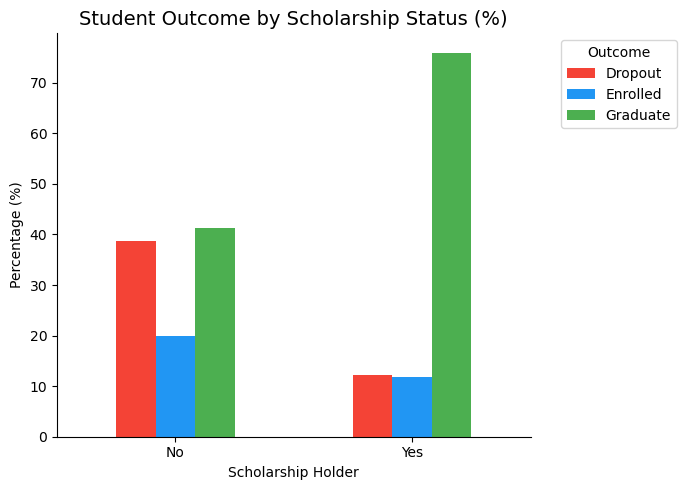

In [20]:
# Dropout rate by scholarship status
schol_target = df.groupby(['Scholarship holder', 'Target']).size().unstack(fill_value=0)
schol_pct = schol_target.div(schol_target.sum(axis=1), axis=0) * 100

schol_pct.plot(kind='bar', figsize=(7, 5), color=['#F44336','#2196F3','#4CAF50'])
plt.title("Student Outcome by Scholarship Status (%)", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Scholarship Holder")
plt.xticks(rotation=0)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("03_outcome_by_scholarship.png", dpi=150)
plt.show()

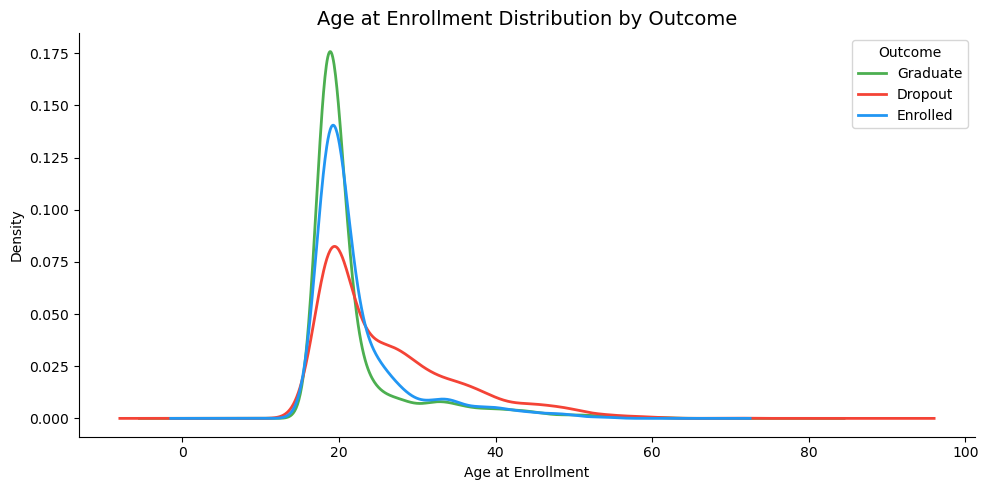

In [21]:
# Age distribution by outcome
fig, ax = plt.subplots(figsize=(10, 5))
for outcome, color in zip(['Graduate', 'Dropout', 'Enrolled'],
                           ['#4CAF50', '#F44336', '#2196F3']):
    subset = df[df['Target'] == outcome]['Age at enrollment']
    subset.plot.kde(ax=ax, label=outcome, color=color, linewidth=2)

ax.set_title("Age at Enrollment Distribution by Outcome", fontsize=14)
ax.set_xlabel("Age at Enrollment")
ax.set_ylabel("Density")
ax.legend(title="Outcome")
plt.tight_layout()
plt.savefig("04_age_distribution.png", dpi=150)
plt.show()

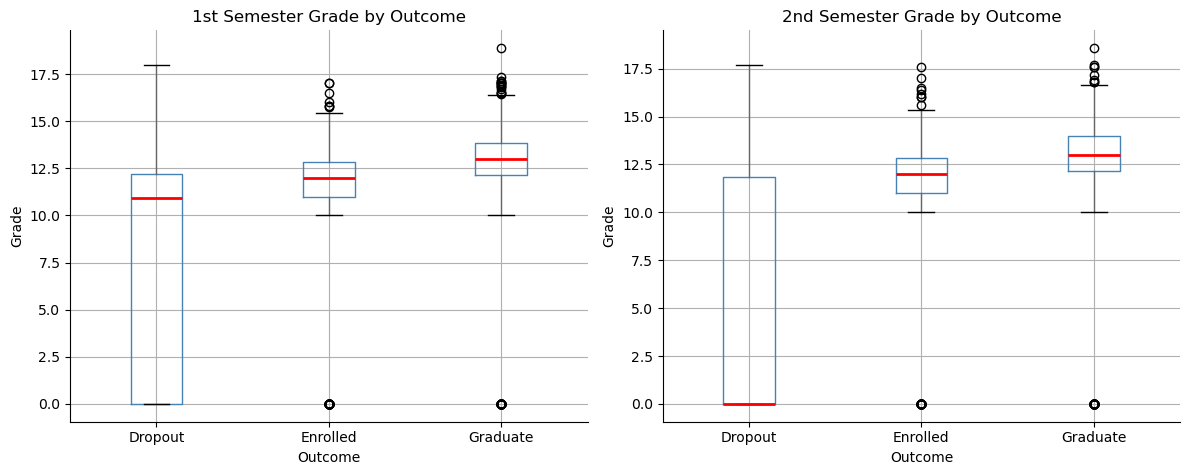

In [22]:
# Academic performance — semester grades by outcome 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
    ['Sem1 grade', 'Sem2 grade'],
    ['1st Semester Grade by Outcome', '2nd Semester Grade by Outcome']):
    
    df.boxplot(column=col, by='Target', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Grade")

plt.suptitle("")
plt.tight_layout()
plt.savefig("05_grades_by_outcome.png", dpi=150)
plt.show()

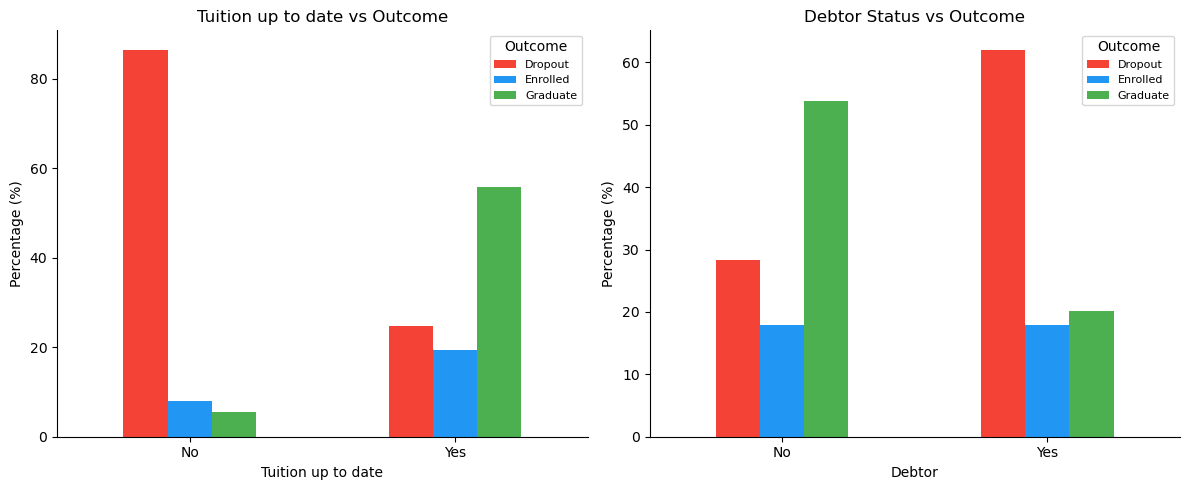

In [23]:
# Financial stress — tuition & debtor status vs dropout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
    ['Tuition up to date', 'Debtor'],
    ['Tuition up to date vs Outcome', 'Debtor Status vs Outcome']):
    
    grp = df.groupby([col, 'Target']).size().unstack(fill_value=0)
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    grp_pct.plot(kind='bar', ax=ax, color=['#F44336','#2196F3','#4CAF50'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title="Outcome", fontsize=8)

plt.tight_layout()
plt.savefig("06_financial_vs_outcome.png", dpi=150)
plt.show()

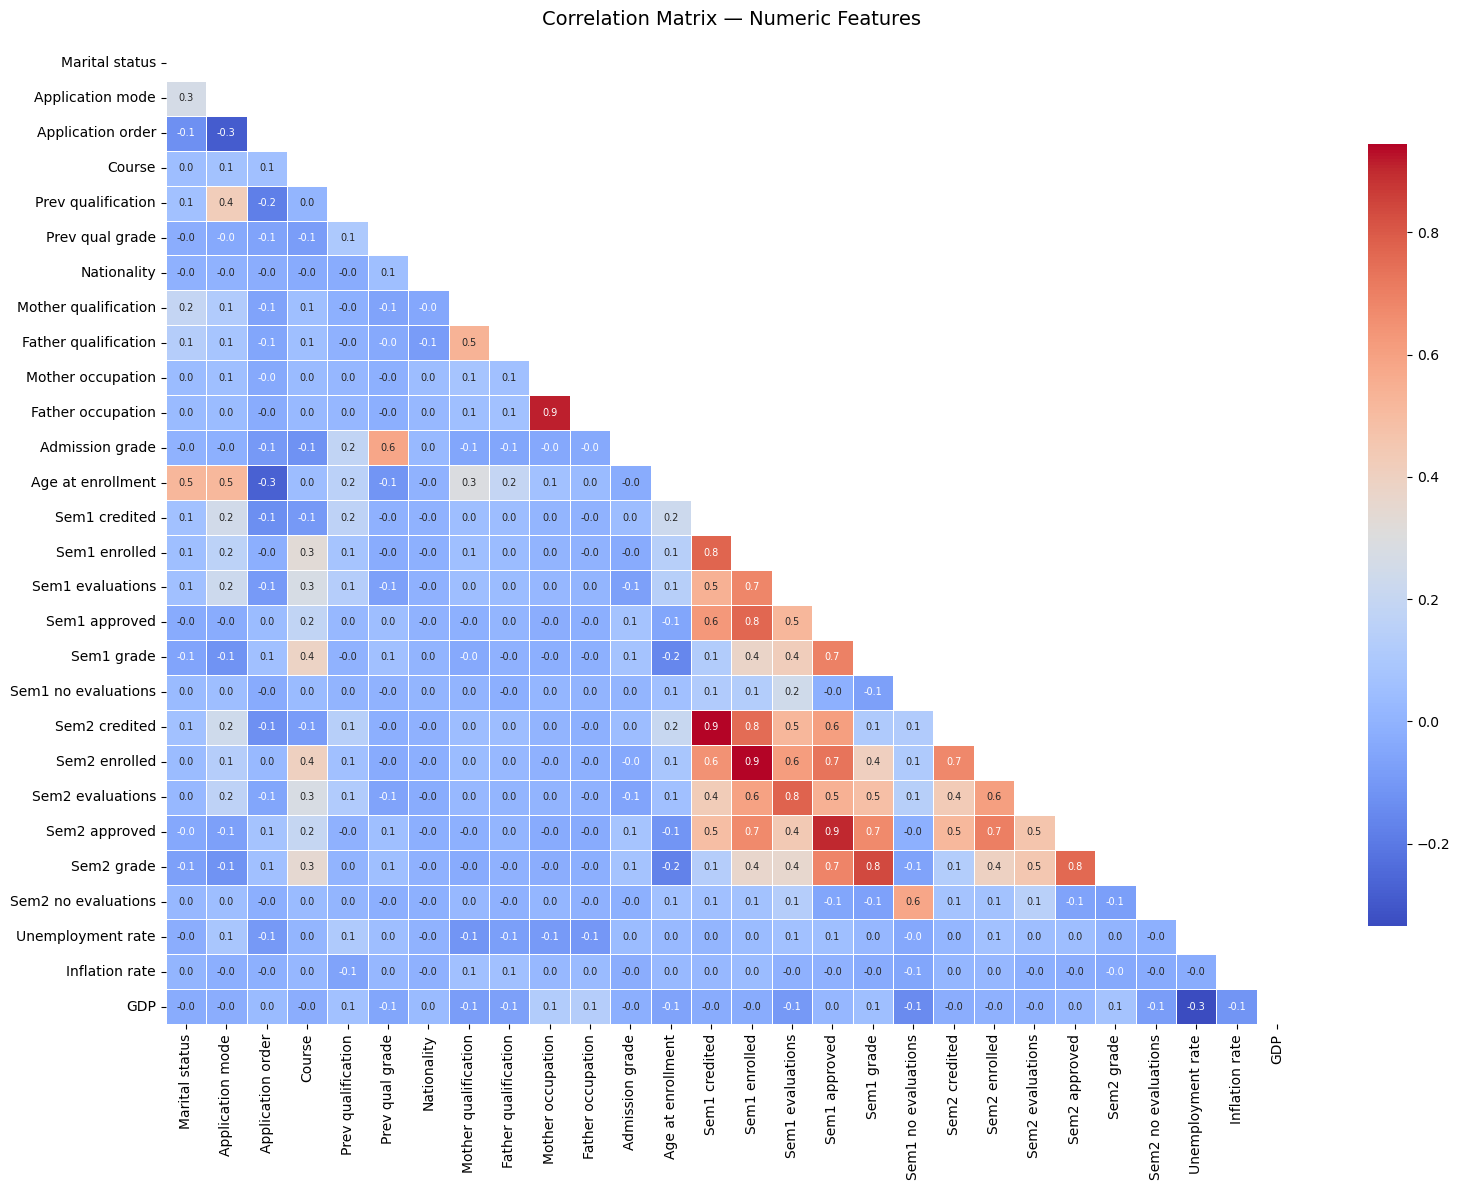

In [24]:
# Correlation heatmap (numeric columns)
num_df = df.select_dtypes(include='number')

plt.figure(figsize=(16, 12))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".1f", cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix — Numeric Features", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("07_correlation_heatmap.png", dpi=150)
plt.show()

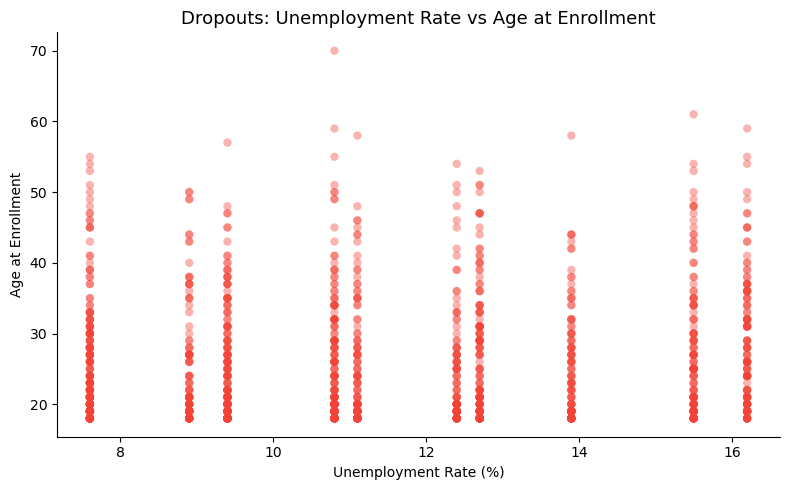

In [25]:
# Macroeconomic context — dropout rate vs unemployment
dropout_df = df[df['Target'] == 'Dropout']

plt.figure(figsize=(8, 5))
plt.scatter(dropout_df['Unemployment rate'], dropout_df['Age at enrollment'],
            alpha=0.4, color='#F44336', edgecolors='none')

plt.title("Dropouts: Unemployment Rate vs Age at Enrollment", fontsize=13)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Age at Enrollment")
plt.tight_layout()
plt.savefig("08_macro_vs_dropout.png", dpi=150)
plt.show()